In [10]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [12]:
from src import metrics
import json
import pandas as pd
from pathlib import Path

In [13]:
PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    run_data = json.load(f)

In [48]:
df["gpt_eval"].mean()

np.float64(0.361)

In [29]:
model_sizes = {
    "gpt-4o-mini": 8,
    "gpt-4o": 200,
    "Llama-3.3-70B": 70,
    "DeepSeek-V3": 37  # use active params for fairness
}

In [49]:
all_metrics_list = []

for run in run_data:
    csv_file = run["csv_file"]
    prompt = run["prompt"]
    dataset = run["dataset"]
    model = run["model"]

    df = pd.read_csv(runs_dir / csv_file)
    metrics_dict = metrics.calculate_metrics(y_true=df["gpt_eval"], y_prob=df["confidence"])
    metrics_dict.update({
        "prompt": prompt,
        "dataset": dataset,
        "accuracy": df["gpt_eval"].mean(),
        "model": model,
        "model_size": model_sizes[model]
    })

    all_metrics_list.append(metrics_dict)

In [50]:
metrics_df = pd.DataFrame(all_metrics_list)

In [51]:
metrics_df

,brier_score,roc_auc,average_precision,ece,prompt,dataset,accuracy,model,model_size
0,0.238837,0.766834,0.829747,0.220291,cot,HotpotQA,0.671343,DeepSeek-V3,37
1,0.230062,0.745740,0.832236,0.201894,multistep,HotpotQA,0.652000,DeepSeek-V3,37
2,0.253315,0.777273,0.750796,0.229270,top-k,HotpotQA,0.529000,DeepSeek-V3,37
3,0.369143,0.643734,0.317458,0.436050,top-k,MuSiQue,0.229000,DeepSeek-V3,37
4,0.337722,0.694011,0.355965,0.411650,direct,MuSiQue,0.219000,DeepSeek-V3,37
5,0.202765,0.685492,0.498170,0.088551,multistep,MuSiQue,0.312000,DeepSeek-V3,37
6,0.275803,0.642739,0.499338,0.226650,direct,2WikiMultihopQA,0.405000,DeepSeek-V3,37
7,0.242725,0.773423,0.761049,0.199100,direct,HotpotQA,0.554000,DeepSeek-V3,37
8,0.259744,0.682222,0.715570,0.189982,multistep,2WikiMultihopQA,0.565000,DeepSeek-V3,37
9,0.468990,0.711271,0.474451,0.514638,cot,MuSiQue,0.322938,DeepSeek-V3,37


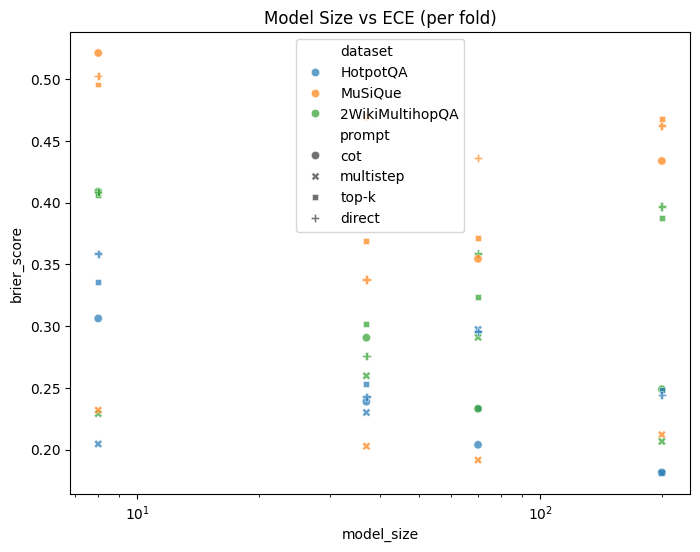

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=metrics_df,
    x="model_size",
    y="brier_score",
    hue="dataset",
    style="prompt",
    alpha=0.7
)

plt.xscale("log")  # important if sizes vary a lot
plt.title("Model Size vs ECE (per fold)")
plt.show()

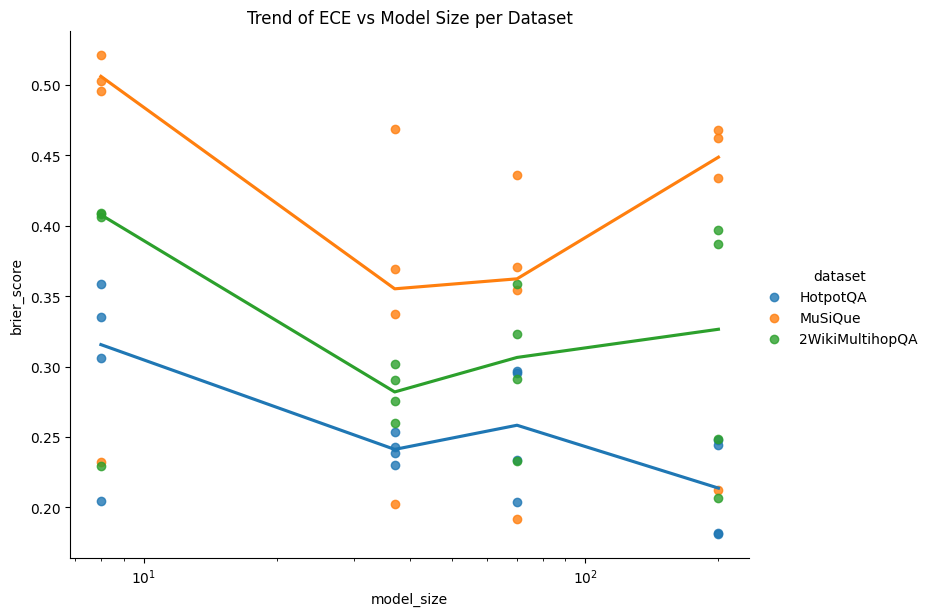

In [57]:
sns.lmplot(
    data=metrics_df,
    x="model_size",
    y="brier_score",
    hue="dataset",
    scatter=True,
    lowess=True,
    height=6,
    aspect=1.3
)

plt.xscale("log")
plt.title("Trend of ECE vs Model Size per Dataset")
plt.show()

In [68]:
metrics_df["ece_norm"] = metrics_df.groupby("dataset")["ece"].transform(
    lambda x: (x - x.mean()) / x.std()
)
metrics_df["brier_score_norm"] = metrics_df.groupby("dataset")["brier_score"].transform(
    lambda x: (x - x.mean()) / x.std()
)

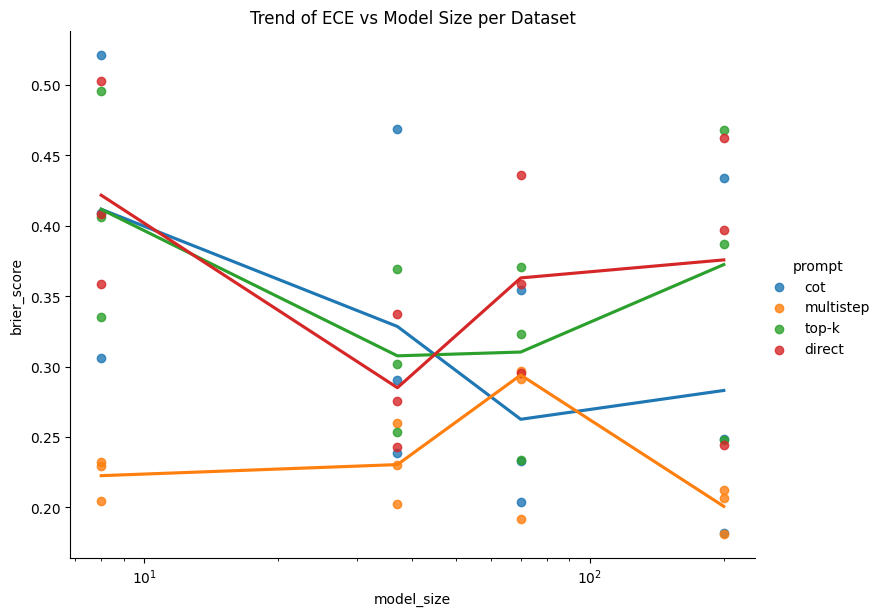

In [69]:
sns.lmplot(
    data=metrics_df,
    x="model_size",
    y="brier_score",
    hue="prompt",
    scatter=True,
    lowess=True,
    height=6,
    aspect=1.3
)

plt.xscale("log")
plt.title("Trend of ECE vs Model Size per Dataset")
plt.show()

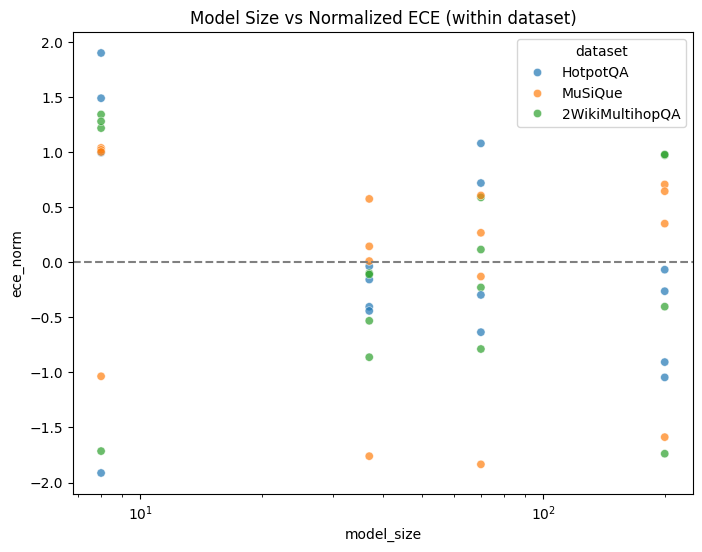

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=metrics_df,
    x="model_size",
    y="ece_norm",
    hue="dataset",
    alpha=0.7
)

plt.xscale("log")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Model Size vs Normalized ECE (within dataset)")
plt.show()

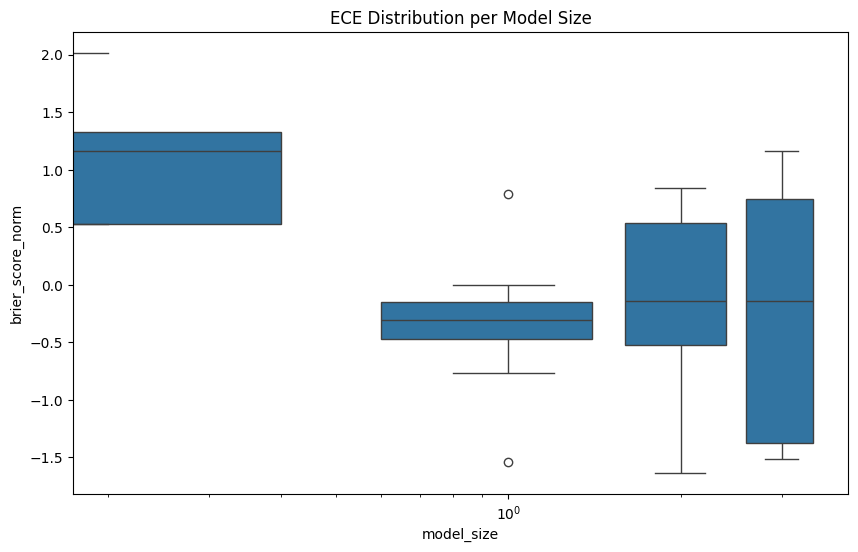

In [74]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=metrics_df,
    x="model_size",
    y="brier_score_norm"
)

plt.xscale("log")
plt.title("ECE Distribution per Model Size")
plt.show()

In [62]:
# assume you stored dataset sizes somewhere
dataset_sizes = metrics_df.groupby("dataset").size()

metrics_df["dataset_weight"] = metrics_df["dataset"].map(dataset_sizes)

agg_df = (
    metrics_df
    .groupby("model_size")
    .apply(lambda x: np.average(x["ece"], weights=x["dataset_weight"]))
    .reset_index(name="weighted_ece")
)

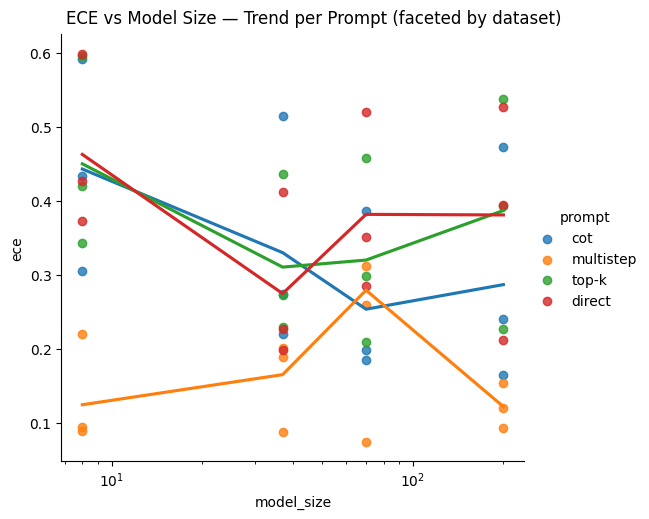

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.lmplot(
    data=metrics_df,
    x="model_size",
    y="ece",
    hue="prompt",          # 🔥 one line per prompt
    lowess=True,
    scatter=True,
    height=5,
    aspect=1.1
)

# log scale AFTER plotting
for ax in g.axes.flat:
    ax.set_xscale("log")

g.fig.suptitle("ECE vs Model Size — Trend per Prompt (faceted by dataset)", y=1.02)
plt.show()

<Axes: xlabel='accuracy', ylabel='ece'>

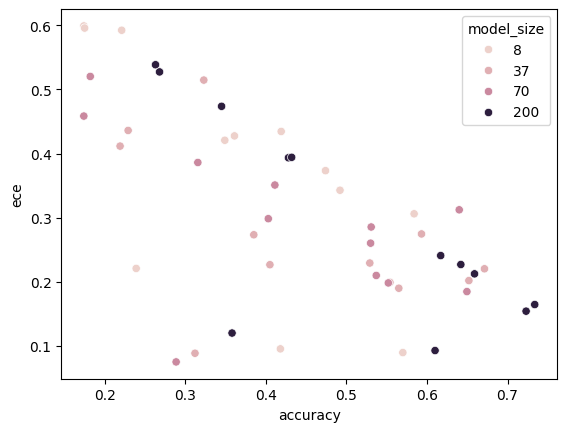

In [72]:
sns.scatterplot(
    data=metrics_df,
    x="accuracy",
    y="ece",
    hue="model_size"
)

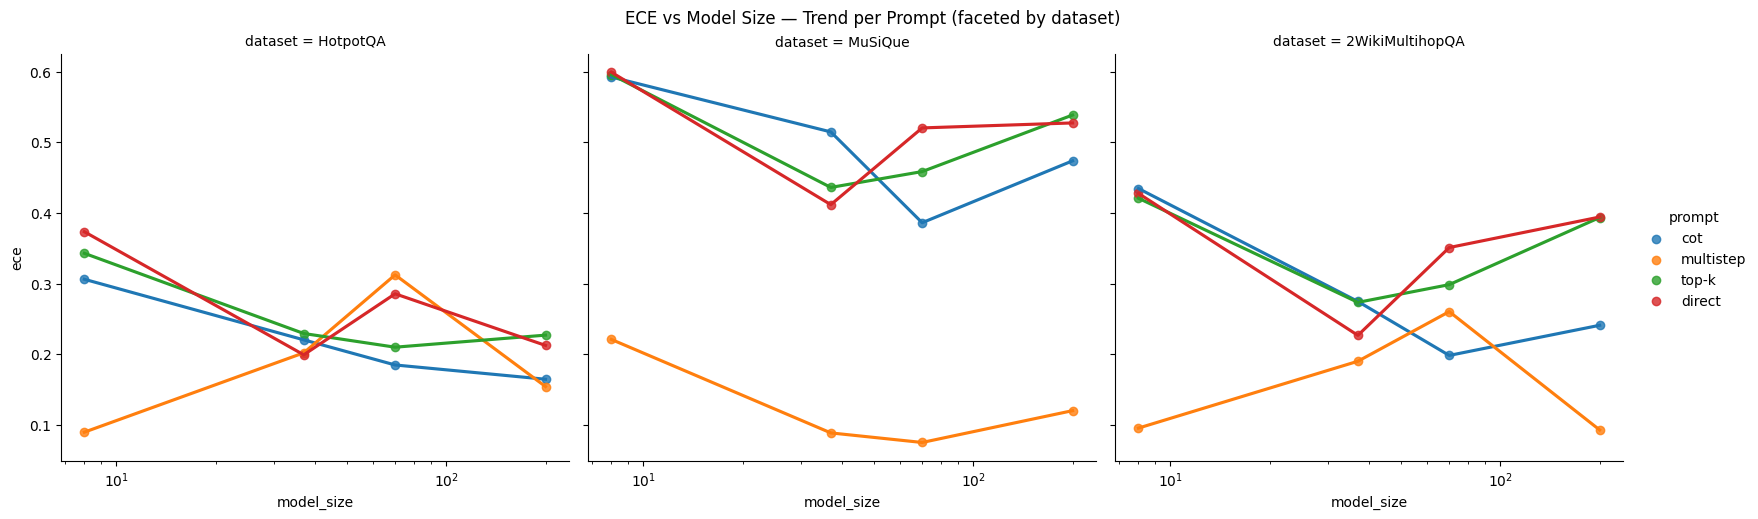

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.lmplot(
    data=metrics_df,
    x="model_size",
    y="ece",
    hue="prompt",          # 🔥 one line per prompt
    col="dataset",         # 👉 separate panels per dataset
    lowess=True,
    scatter=True,
    height=5,
    aspect=1.1
)

# log scale AFTER plotting
for ax in g.axes.flat:
    ax.set_xscale("log")

g.fig.suptitle("ECE vs Model Size — Trend per Prompt (faceted by dataset)", y=1.02)
plt.show()

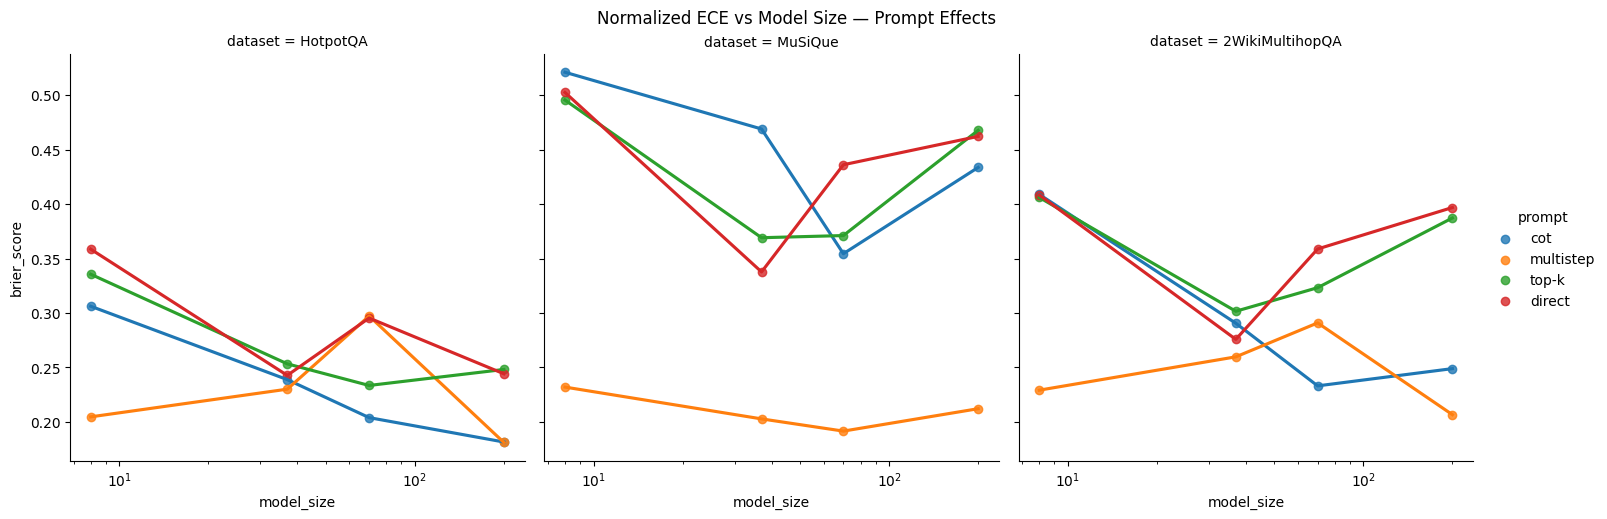

In [80]:
g = sns.lmplot(
    data=metrics_df,
    x="model_size",
    y="brier_score",
    hue="prompt",
    col="dataset",
    lowess=True,
    scatter=True,
    height=5
)

for ax in g.axes.flat:
    ax.set_xscale("log")

g.fig.suptitle("Normalized ECE vs Model Size — Prompt Effects", y=1.02)
plt.show()